## Descriptive Statistics

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv(os.path.join("..", "data", "processed", "cardio_onc_prostate_04cleaned.csv"))

bins = np.arange(45, df['age'].max(), 5)
labels = [f"{int(b)}–{int(b+4)}" for b in bins[:-1]]
df['age_bin'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

tox = df[df['at_risk'] == 1]
no_tox = df[df['at_risk'] == 0]

Descriptives of At Risk Patients

In [6]:
cont_vars = ['age','bmi','ascvd_10yr','sbp','dbp']

table1_cont = df.groupby('at_risk')[cont_vars].agg(['mean','std'])

print(table1_cont)

cat_vars = [
    'ethnicity','hx_smoking','hx_htn','hx_hld','hx_dm2',
    'hx_cad','hx_chf','hx_arrhythmia','hx_pad','hx_cva',
    'has_pcp','lipid_panel_checked','a1c_checked',
    'cards_prior','diet_counseling','exercise_counseling'
]

table1_cat = {}

for v in cat_vars:
    table1_cat[v] = pd.crosstab(df['at_risk'], df[v], normalize='columns') * 100

for k,v in table1_cat.items():
    print("\n",k)
    print(v)

               age                  bmi           ascvd_10yr            \
              mean       std       mean       std       mean       std   
at_risk                                                                  
0.0      71.766129  9.337492  27.801290  5.194846   1.774194  0.419809   
1.0      71.405063  8.460343  27.521266  5.080351   1.835443  0.373149   

                sbp                   dbp            
               mean        std       mean       std  
at_risk                                              
0.0      129.733871  13.662666  73.629032  7.867260  
1.0      130.759494  14.506599  73.392405  8.662353  

 ethnicity
ethnicity      Asian      Black  Caucasian   Hispanic      Other
at_risk                                                         
0.0        55.555556  47.058824  64.545455  68.181818  47.826087
1.0        44.444444  52.941176  35.454545  31.818182  52.173913

 hx_smoking
hx_smoking          0          1
at_risk                         
0.0     

### Baseline Demographics
Age

C:\Users\tiffa\AppData\Local\Temp\ipykernel_27760\3982113523.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_bin', 'at_risk'])['unique_patient_id']


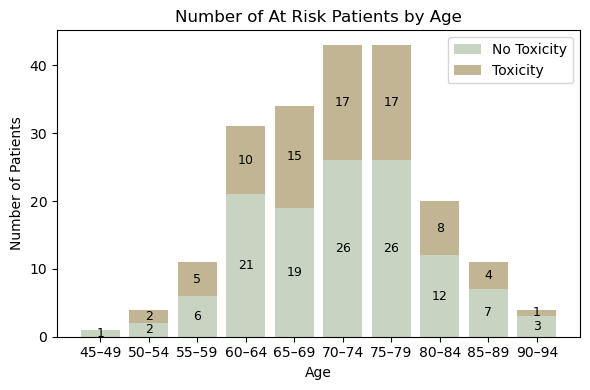

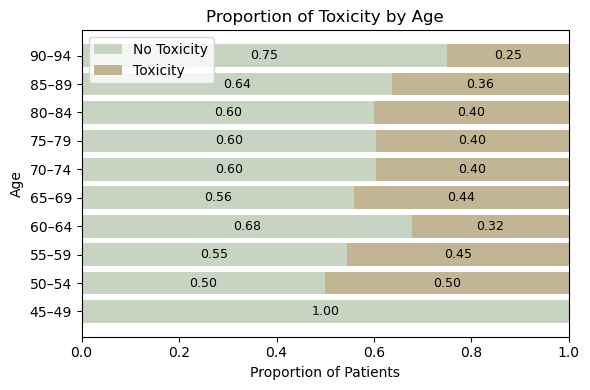

In [144]:
counts = (
    df.groupby(['age_bin', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).index]

fig, ax = plt.subplots(figsize=(6,4))

bars_no = ax.bar(counts.index.astype(str), counts[0], color='#c7d4c1', label='No Toxicity')

bars_yes = ax.bar(counts.index.astype(str), counts[1], bottom=counts[0], color='#c2b594', label='Toxicity')

labels_no = [str(v) if v > 0 else "" for v in counts[0]]
labels_yes = [str(v) if v > 0 else "" for v in counts[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Age')
ax.set_ylabel('Number of Patients')
ax.set_title('Number of At Risk Patients by Age')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Age')
ax.set_title('Proportion of Toxicity by Age')
ax.legend()

plt.tight_layout()
plt.show()

Ethnicity

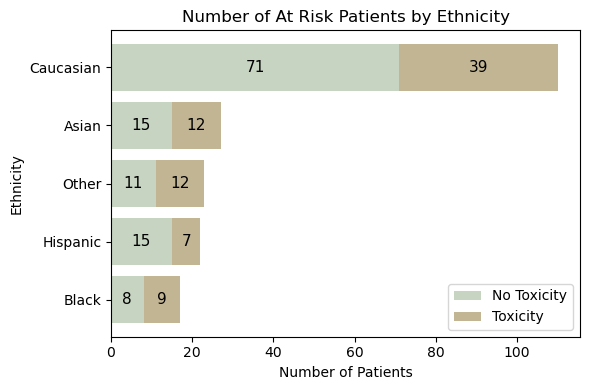

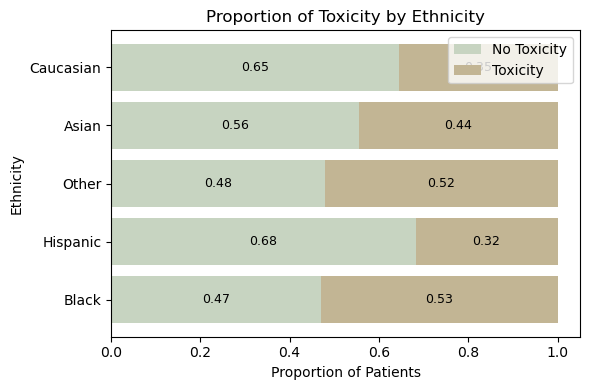

In [143]:

counts = (
    df.groupby(['ethnicity', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts[counts.sum(axis=1) >= 5]

# Count

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

counts = counts[counts.sum(axis=1) >= 2]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, label_type='center', fontsize=11)
ax.bar_label(bars_yes, label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Ethnicity')
ax.set_title('Number of At Risk Patients by Ethnicity')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Ethnicity')
ax.set_title('Proportion of Toxicity by Ethnicity')
ax.legend()

plt.tight_layout()
plt.show()

BMI

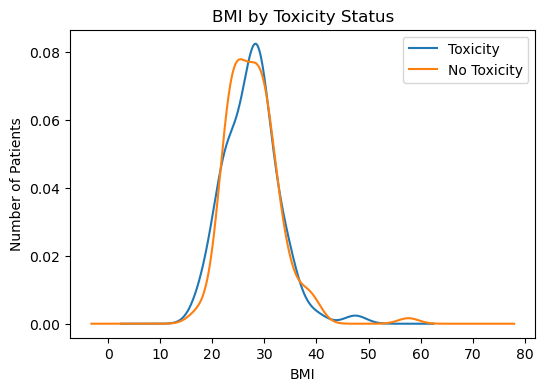

Median BMI (No Toxicity): 27.41
Median BMI (Toxicity): 27.60
Median Difference (Yes - No): 0.20
p-value: 0.8580


In [38]:
tox_bmi = df[df['at_risk'] == 1]['bmi']
no_tox_bmi = df[df['at_risk'] == 0]['bmi']

tox_bmi.dropna().plot(kind='density', figsize=(6,4), label='Toxicity')
no_tox_bmi.dropna().plot(kind='density', figsize=(6,4), label='No Toxicity')

plt.xlabel('BMI')
plt.ylabel('Number of Patients')
plt.title('BMI by Toxicity Status')
plt.legend()

plt.show()

bmi_summary = df.groupby('at_risk')['bmi'].median()
median_no = bmi_summary[0]
median_yes = bmi_summary[1]

median_diff = median_yes - median_no

print(f"Median BMI (No Toxicity): {median_no:.2f}")
print(f"Median BMI (Toxicity): {median_yes:.2f}")
print(f"Median Difference (Yes - No): {median_diff:.2f}")

from scipy.stats import mannwhitneyu

bmi_no = df[df['at_risk'] == 0]['bmi'].dropna()
bmi_yes = df[df['at_risk'] == 1]['bmi'].dropna()

stat, pval = mannwhitneyu(bmi_yes, bmi_no, alternative='two-sided')

print(f"p-value: {pval:.4f}")

Proportion of Patients in Toxicity Group that had Baseline Disease

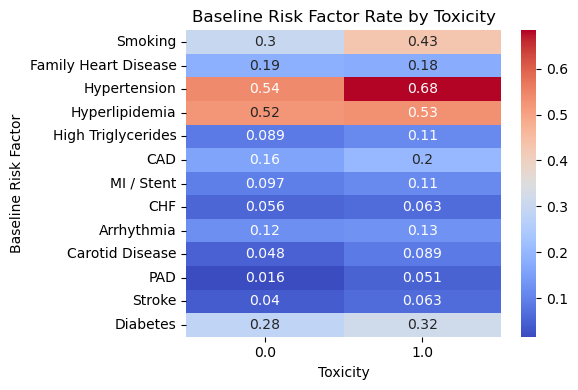

In [40]:
risk_vars = ["hx_smoking", "family_hx_hd", 'hx_htn', 'hx_hld', 'hx_high_tg', 'hx_cad', 
             'hx_mi_stent', 'hx_chf', 'hx_arrhythmia', 'hx_carotid', 'hx_pad', 'hx_cva', 'hx_dm2']

condition_names = {
    "hx_smoking": "Smoking",
    "family_hx_hd": "Family Heart Disease",
    "hx_htn": "Hypertension",
    "hx_hld": "Hyperlipidemia",
    "hx_high_tg": "High Triglycerides",
    "hx_cad": "CAD",
    "hx_mi_stent": "MI / Stent",
    "hx_chf": "CHF",
    "hx_arrhythmia": "Arrhythmia",
    "hx_carotid": "Carotid Disease",
    "hx_pad": "PAD",
    "hx_cva": "Stroke",
    "hx_dm2": "Diabetes"
}

heat = df.groupby('at_risk')[risk_vars].mean().T
heat.index = heat.index.map(condition_names)

plt.figure(figsize=(6,4))
sns.heatmap(heat, annot=True, cmap="coolwarm")
plt.title("Baseline Risk Factor Rate by Toxicity")
plt.xlabel("Toxicity")
plt.ylabel("Baseline Risk Factor")
plt.tight_layout()

Proportion of Patients with Baseline Disease that Developed Toxicity

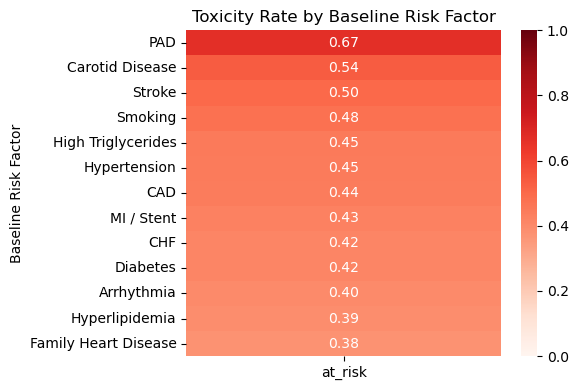

In [39]:
heatmap_data = []

health_cols = ["hx_smoking", "family_hx_hd", 'hx_htn', 'hx_hld', 'hx_high_tg', 'hx_cad', 'hx_mi_stent', 'hx_chf', 'hx_arrhythmia', 'hx_carotid', 'hx_pad', 'hx_cva', 'hx_dm2']

#affected if hx_smoking = 1 or 2, family_hx_hd = 1, hx_htn=1, hx_hld=1, hx_high_tg=1, hx_cad =1, hx_mi_stent=1, hx_chf=1, hx_arrhythmia=1, hx_carotid=1, hx_pad=1, hx_cva=1, hx_dm2=1

condition_filter = {
    "hx_smoking": lambda x: x >= 1,
    "family_hx_hd": lambda x: x == 1,
    'hx_htn': lambda x: x == 1,
    'hx_hld': lambda x: x == 1,
    'hx_high_tg': lambda x: x == 1,
    'hx_cad': lambda x: x == 1,
    'hx_mi_stent': lambda x: x == 1,
    'hx_chf': lambda x: x == 1,
    'hx_arrhythmia': lambda x: x == 1,
    'hx_carotid': lambda x: x == 1,
    'hx_pad': lambda x: x == 1,
    'hx_cva': lambda x: x == 1,
    'hx_dm2': lambda x: x == 1
}

condition_names = {
    "hx_smoking": "Smoking",
    "family_hx_hd": "Family Heart Disease",
    "hx_htn": "Hypertension",
    "hx_hld": "Hyperlipidemia",
    "hx_high_tg": "High Triglycerides",
    "hx_cad": "CAD",
    "hx_mi_stent": "MI / Stent",
    "hx_chf": "CHF",
    "hx_arrhythmia": "Arrhythmia",
    "hx_carotid": "Carotid Disease",
    "hx_pad": "PAD",
    "hx_cva": "Stroke",
    "hx_dm2": "Diabetes"
}

for col in health_cols:
    subset = df[condition_filter[col](df[col])]
    
    tox_value = subset['at_risk'].mean()
     
    heatmap_data.append({
        "condition": col,
        "at_risk": tox_value
    })

heatmap_df = pd.DataFrame(heatmap_data).set_index("condition")
heatmap_df.index = heatmap_df.index.map(condition_names)
heatmap_df = heatmap_df.sort_values("at_risk", ascending=False)

plt.figure(figsize=(6,4))

ax=sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=1,
    fmt=".2f",
    annot_kws={"color": "white", "fontsize": 10}
)

ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.title("Toxicity Rate by Baseline Risk Factor")
plt.xlabel("")
plt.ylabel("Baseline Risk Factor")

plt.tight_layout()
plt.show()

### ADT and NHT Measures

NHT Counts

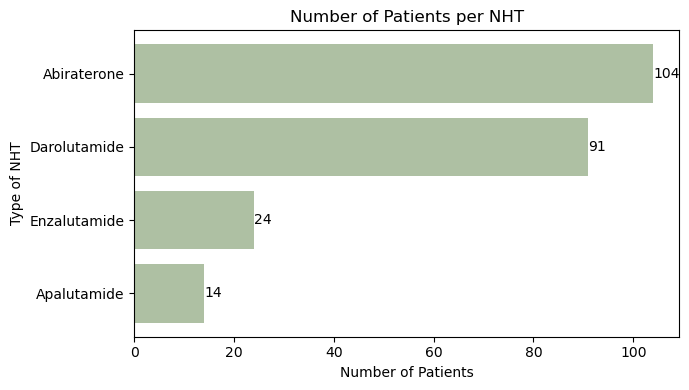

In [79]:
# Count unique patients per NHT
num_patients = df.groupby('specific_nht_used')['unique_patient_id'].nunique()

num_patients = num_patients.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

p=ax.barh(num_patients.index, num_patients.values,
          color='#aec0a3')
ax.bar_label(p, label_type='edge')
ax.set_ylabel('Type of NHT')
ax.set_xlabel('Number of Patients')
ax.set_title('Number of Patients per NHT')
plt.tight_layout()
plt.show()

ADT Counts

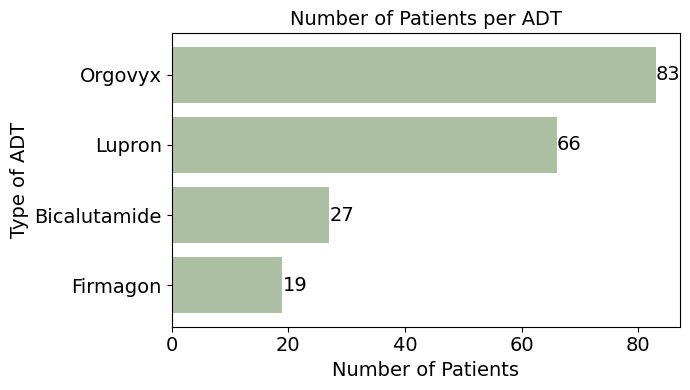

In [80]:
# Count unique patients per ADT
num_patients = df.groupby('adt_agent')['unique_patient_id'].nunique()

num_patients = num_patients.sort_values(ascending=True)


fig, ax = plt.subplots(figsize=(7,4))

ax.barh(num_patients.index, num_patients.values)
p=ax.barh(num_patients.index, num_patients.values, color='#aec0a3')
ax.bar_label(p, label_type='edge', fontsize=14)
ax.set_ylabel('Type of ADT', fontsize=14)
ax.set_xlabel('Number of Patients', fontsize=14)
ax.set_title('Number of Patients per ADT', fontsize=14)
ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

NHT and ADT Combinations

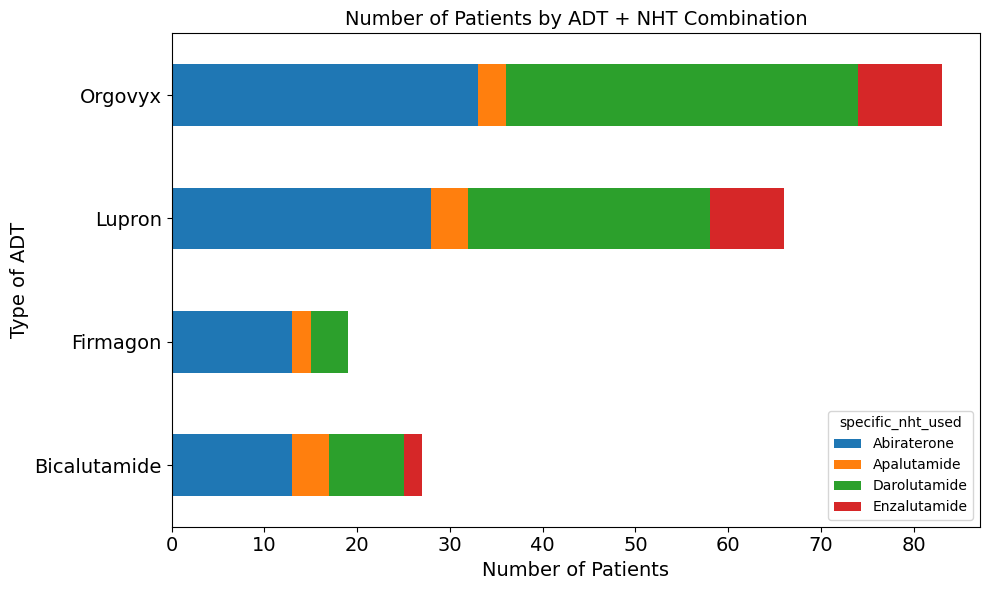

In [45]:
combo_counts = (
    df.groupby(['adt_agent', 'specific_nht_used'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(10,6))

combo_counts.plot(
    kind='barh',
    stacked=True,
    ax=ax
)

ax.set_ylabel('Type of ADT', fontsize=14)
ax.set_xlabel('Number of Patients', fontsize=14)
ax.set_title('Number of Patients by ADT + NHT Combination', fontsize=14)

ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

Toxicity by NHT

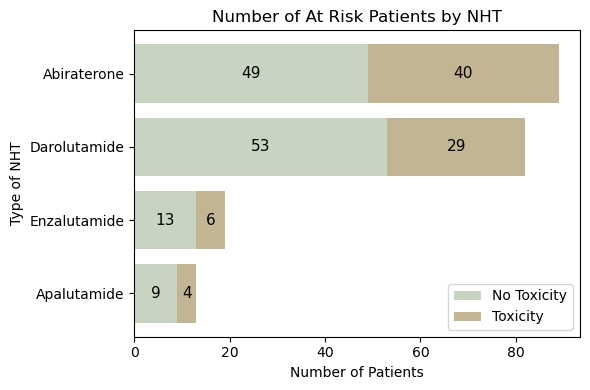

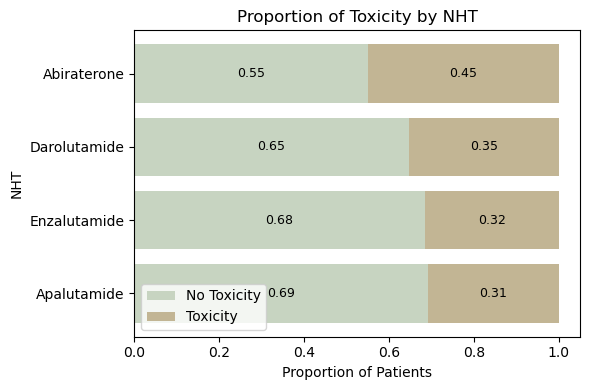

In [142]:
counts = (
    df.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, label_type='center', fontsize=11)
ax.bar_label(bars_yes, label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('NHT')
ax.set_title('Proportion of Toxicity by NHT')
ax.legend()

plt.tight_layout()
plt.show()

Toxicity by ADT

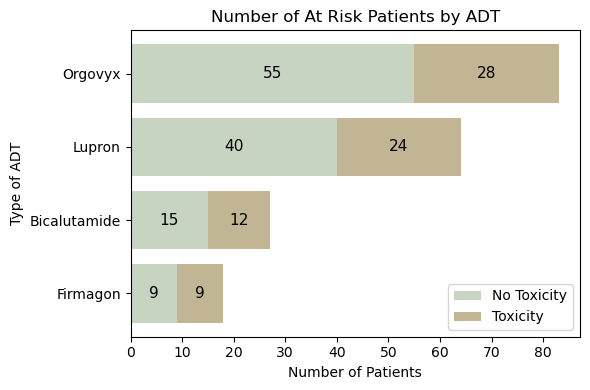

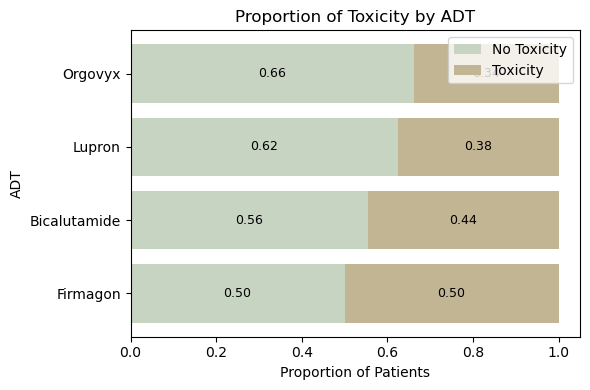

In [141]:
# Counts

counts = (
    df.groupby(['adt_agent', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, label_type='center', fontsize=11)
ax.bar_label(bars_yes, label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of ADT')
ax.set_title('Number of At Risk Patients by ADT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('ADT')
ax.set_title('Proportion of Toxicity by ADT')
ax.legend()

plt.tight_layout()
plt.show()

Darolutimide vs. Abiraterone Significance

In [70]:
rates = df.groupby('specific_nht_used')['at_risk'].mean()

risk_diff = rates['Abiraterone'] - rates['Darolutamide']

print(rates)
print("Risk difference of Abiraterone vs. Darolutamide:", risk_diff)

from scipy.stats import chi2_contingency

table = pd.crosstab(df['specific_nht_used'], df['at_risk'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square p-value:", p)

specific_nht_used
Abiraterone     0.449438
Apalutamide     0.307692
Darolutamide    0.353659
Enzalutamide    0.315789
Name: at_risk, dtype: float64
Risk difference of Abiraterone vs. Darolutamide: 0.09577966566182516
Chi-square p-value: 0.45953591634456303


Orgovyx vs. Lupron

In [72]:
rates = df.groupby('adt_agent')['at_risk'].mean()

risk_diff = rates['Lupron'] - rates['Orgovyx']

print(rates)
print("Risk difference of Lupron vs. Orgovyx:", risk_diff)

from scipy.stats import chi2_contingency

table = pd.crosstab(df['adt_agent'], df['at_risk'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square p-value:", p)

adt_agent
Bicalutamide    0.444444
Firmagon        0.500000
Lupron          0.375000
Orgovyx         0.337349
Name: at_risk, dtype: float64
Risk difference of Lupron vs. Orgovyx: 0.03765060240963858
Chi-square p-value: 0.5273839030836365


Toxcity Rate by ADT and NHT Combination

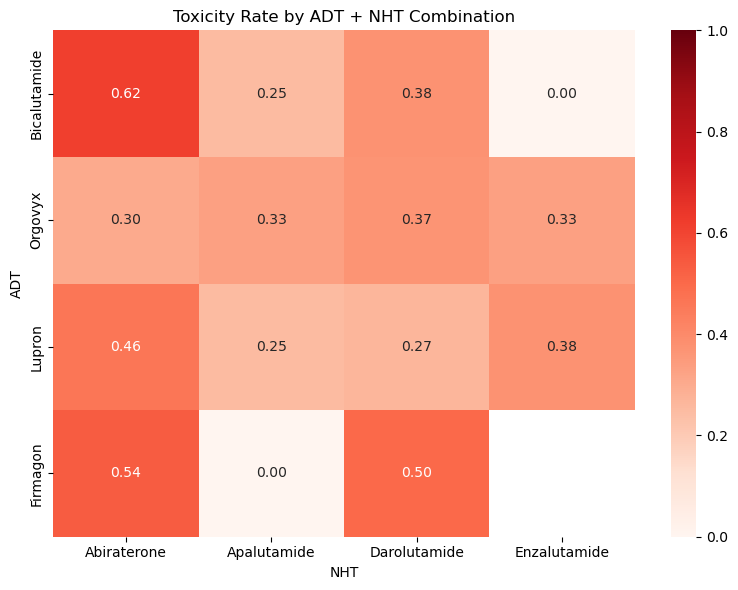

In [74]:
total_counts = (
    df.groupby(['adt_agent', 'specific_nht_used'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

tox_counts = (
    tox.groupby(['adt_agent', 'specific_nht_used'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

tox_counts = tox_counts.reindex(
    index=total_counts.index,
    columns=total_counts.columns,
    fill_value=0
)

valid_rows = total_counts.sum(axis=1) > 3
valid_cols = total_counts.sum(axis=0) > 3

total_counts = total_counts.loc[valid_rows, valid_cols]
tox_counts = tox_counts.loc[valid_rows, valid_cols]

tox_rate = tox_counts.div(total_counts.replace(0, np.nan))

tox_rate = tox_rate.loc[tox_rate.mean(axis=1).sort_values().index]

plt.figure(figsize=(8,6))

ax = sns.heatmap(
    tox_rate,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    vmin=0,
    vmax=1
)

ax.set_xlabel("NHT")
ax.set_ylabel("ADT")
ax.set_title("Toxicity Rate by ADT + NHT Combination")

plt.tight_layout()
plt.show()

Top Four Combination Toxicity

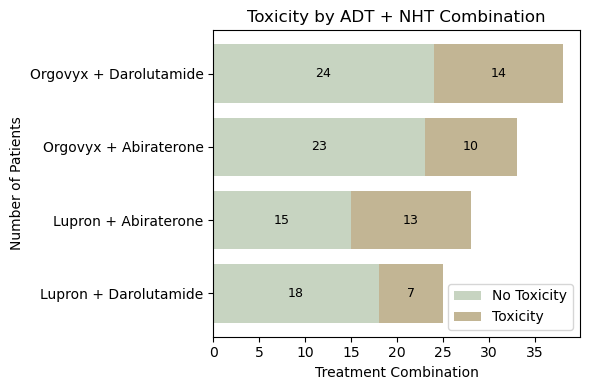

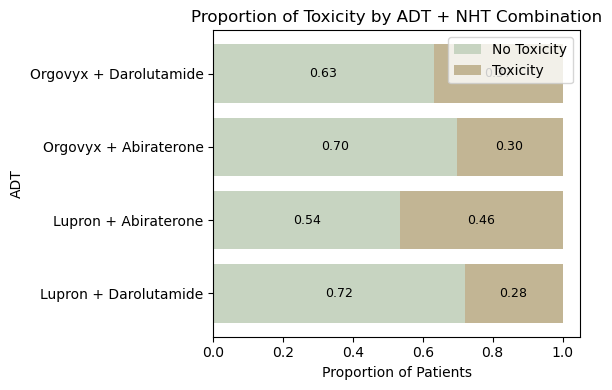

In [129]:
subset = df[
    df['adt_agent'].isin(['Orgovyx', 'Lupron']) &
    df['specific_nht_used'].isin(['Darolutamide', 'Abiraterone'])
].copy()

subset['combo'] = subset['adt_agent'] + " + " + subset['specific_nht_used']

counts = (
    subset.groupby(['combo', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(6,4))

bars_no = ax.barh(counts.index, counts[0],
                 color='#c7d4c1', label='No Toxicity')

bars_yes = ax.barh(counts.index, counts[1],
                  left=counts[0],
                  color='#c2b594', label='Toxicity')

for container in [bars_no, bars_yes]:
    ax.bar_label(container, label_type='center', fontsize=9)

ax.set_xlabel('Treatment Combination')
ax.set_ylabel('Number of Patients')
ax.set_title('Toxicity by ADT + NHT Combination')
ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('ADT')
ax.set_title('Proportion of Toxicity by ADT + NHT Combination')
ax.legend()

plt.tight_layout()
plt.show()

All Combinations

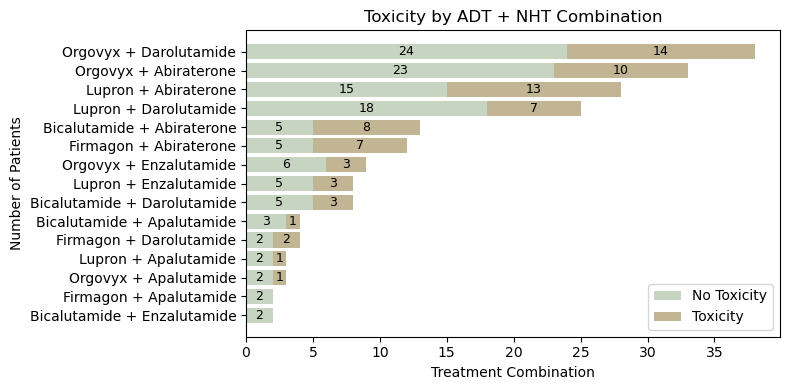

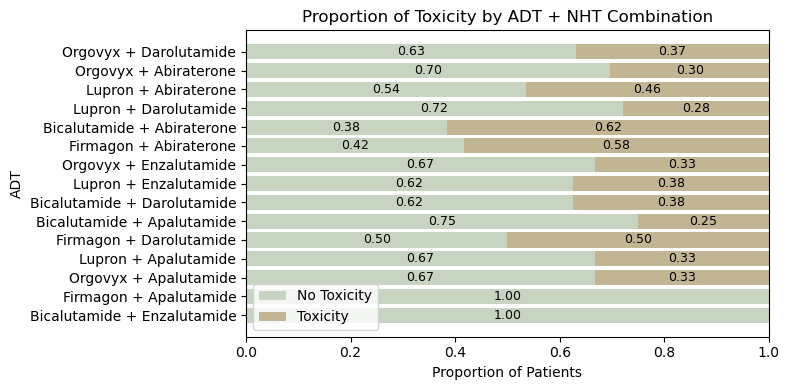

In [128]:
df['combo'] = df['adt_agent'] + " + " + df['specific_nht_used']

counts = (
    df.groupby(['combo', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(8,4))

bars_no = ax.barh(counts.index, counts[0],
                 color='#c7d4c1', label='No Toxicity')

bars_yes = ax.barh(counts.index, counts[1],
                  left=counts[0],
                  color='#c2b594', label='Toxicity')

labels_no = [str(v) if v > 0 else "" for v in counts[0]]
labels_yes = [str(v) if v > 0 else "" for v in counts[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Treatment Combination')
ax.set_ylabel('Number of Patients')
ax.set_title('Toxicity by ADT + NHT Combination')
ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('ADT')
ax.set_title('Proportion of Toxicity by ADT + NHT Combination')
ax.legend()

plt.tight_layout()
plt.show()

### Time Period Length Between ADT and NHT Start

Overall

In [ ]:
df['days_adt_to_nht'].describe()

count      192.000000
mean       509.213542
std       3146.876234
min       -731.000000
25%          0.000000
50%         28.000000
75%        184.750000
max      42759.000000
Name: days_adt_to_nht, dtype: float64

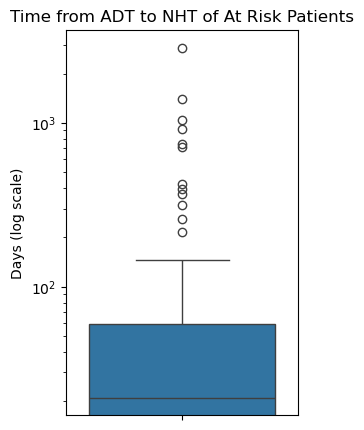

In [50]:
plt.figure(figsize=(3,5))

sns.boxplot(data=tox, y='days_adt_to_nht')

plt.yscale('log')

plt.title("Time from ADT to NHT of At Risk Patients")
plt.ylabel("Days (log scale)")

plt.show()

Split by NHTs

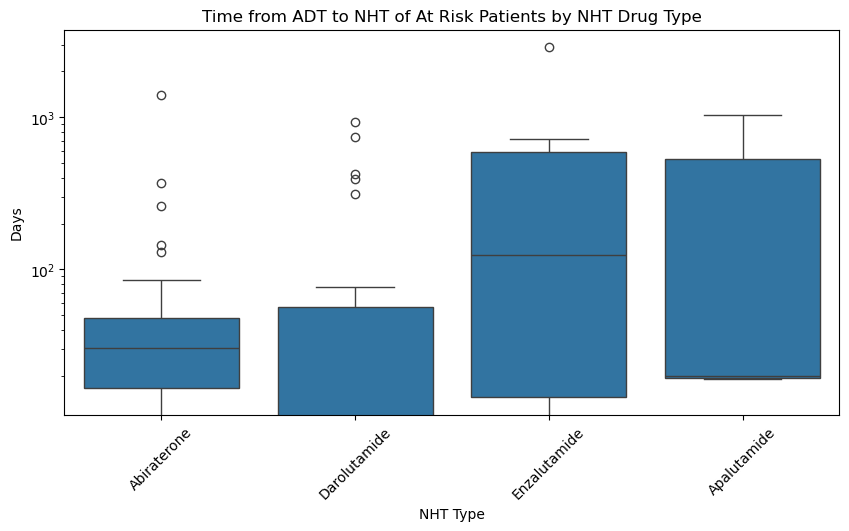

In [51]:
plt.figure(figsize=(10,5))
sns.boxplot(data=tox, x='specific_nht_used', y='days_adt_to_nht')
plt.yscale('log')
plt.xticks(rotation=45)
plt.title("Time from ADT to NHT of At Risk Patients by NHT Drug Type")
plt.xlabel("NHT Type")
plt.ylabel("Days")
plt.show()

### Health History vs. NHT

History of Hypertension

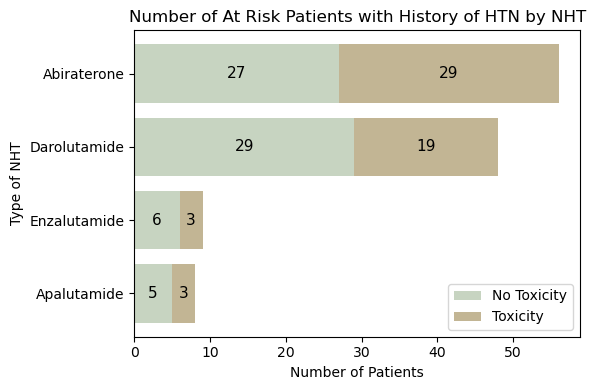

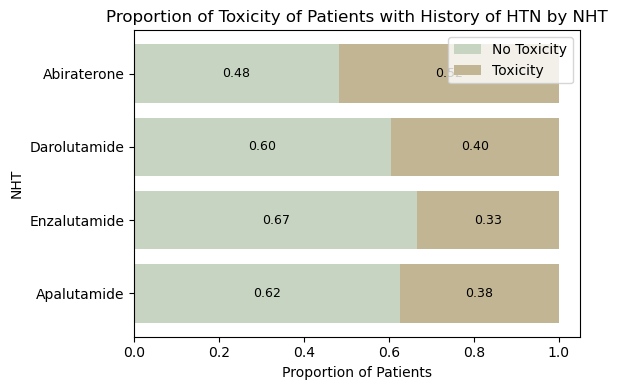

In [131]:
# Counts
htn = df[df['hx_htn'] == 1]

counts = (
    htn.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, label_type='center', fontsize=11)
ax.bar_label(bars_yes, label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with History of HTN by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion
fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('NHT')
ax.set_title('Proportion of Toxicity of Patients with History of HTN by NHT')
ax.legend()

plt.tight_layout()
plt.show()

History of Hyperlipidemia

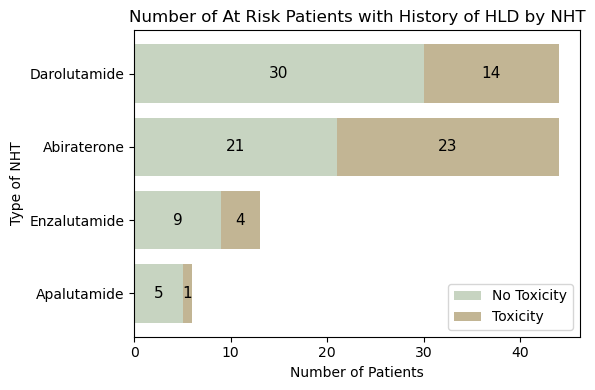

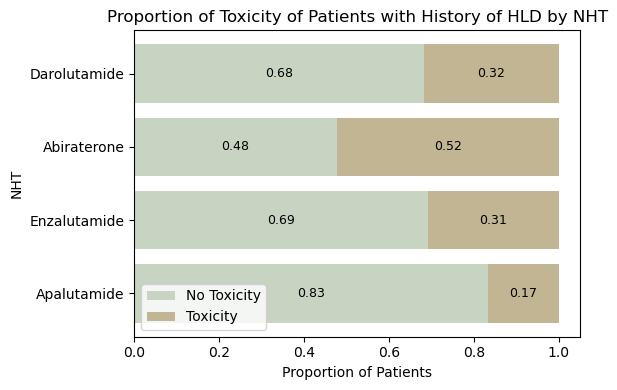

In [132]:
# Counts
hld = df[df['hx_hld'] == 1]

counts = (
    hld.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, label_type='center', fontsize=11)
ax.bar_label(bars_yes, label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with History of HLD by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('NHT')
ax.set_title('Proportion of Toxicity of Patients with History of HLD by NHT')
ax.legend()

plt.tight_layout()
plt.show()

History of Diabetes

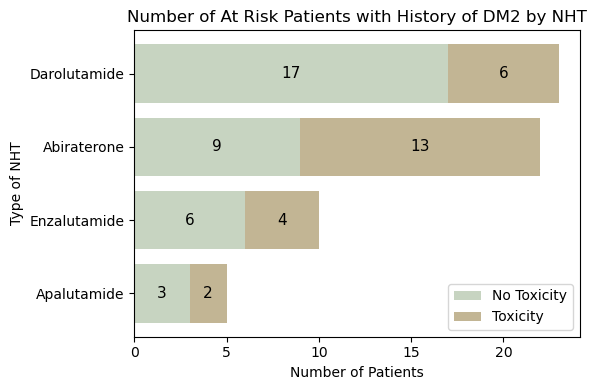

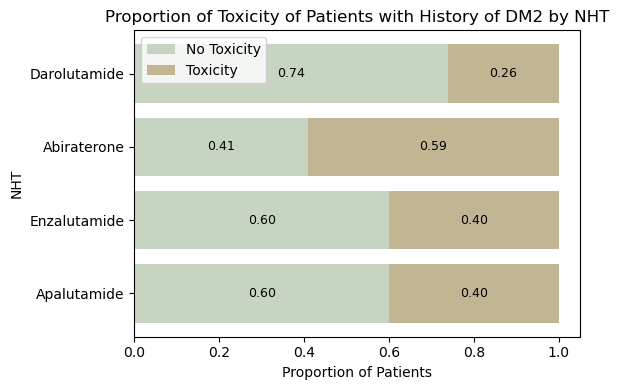

In [133]:
# Counts

dm2 = df[df['hx_dm2'] == 1]

counts = (
    dm2.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, label_type='center', fontsize=11)
ax.bar_label(bars_yes, label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with History of DM2 by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('NHT')
ax.set_title('Proportion of Toxicity of Patients with History of DM2 by NHT')
ax.legend()

plt.tight_layout()
plt.show()

History of MI / Stent

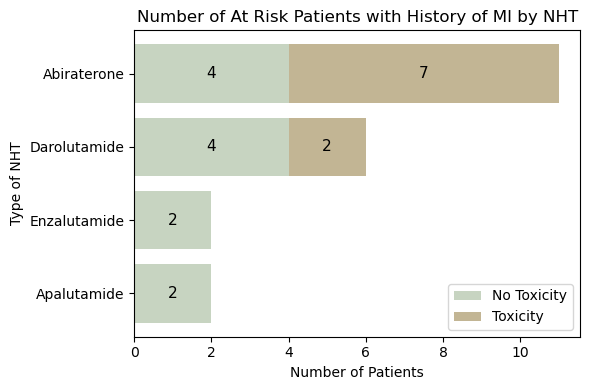

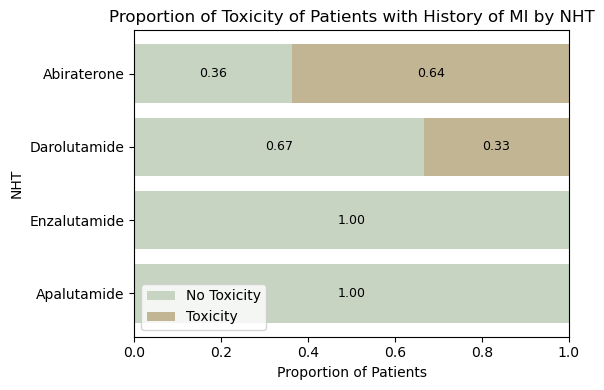

In [134]:
# Counts

mi = df[df['hx_mi_stent'] == 1]

counts = (
    mi.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, label_type='center', fontsize=11)
ax.bar_label(bars_yes, labels=[str(v) if v > 0 else "" for v in counts[1]], label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with History of MI by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('NHT')
ax.set_title('Proportion of Toxicity of Patients with History of MI by NHT')
ax.legend()

plt.tight_layout()
plt.show()

History of CHF

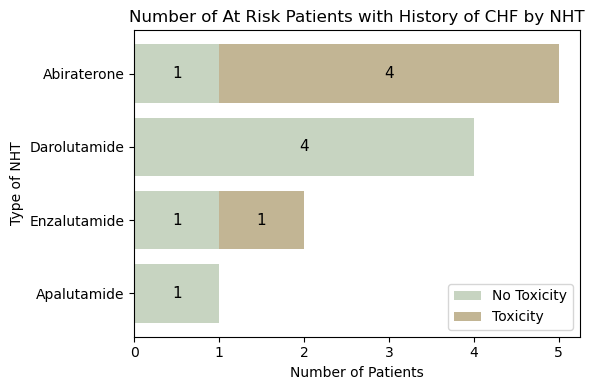

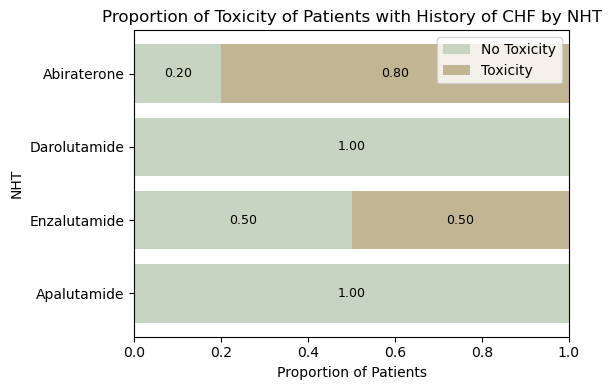

In [135]:
# Counts

chf = df[df['hx_chf'] == 1]

counts = (
    chf.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, labels=[str(v) if v > 0 else "" for v in counts[0]], label_type='center', fontsize=11)
ax.bar_label(bars_yes, labels=[str(v) if v > 0 else "" for v in counts[1]], label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with History of CHF by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('NHT')
ax.set_title('Proportion of Toxicity of Patients with History of CHF by NHT')
ax.legend()

plt.tight_layout()
plt.show()

History of Arrhythmia

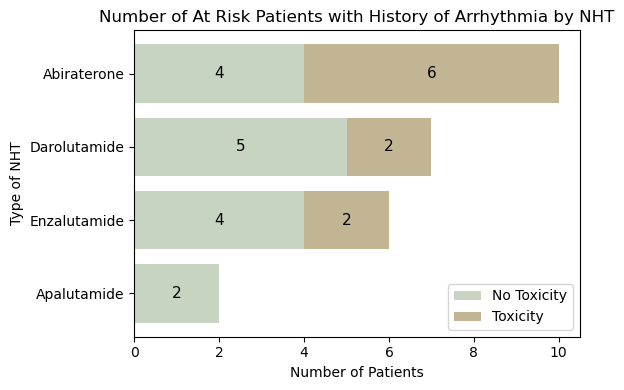

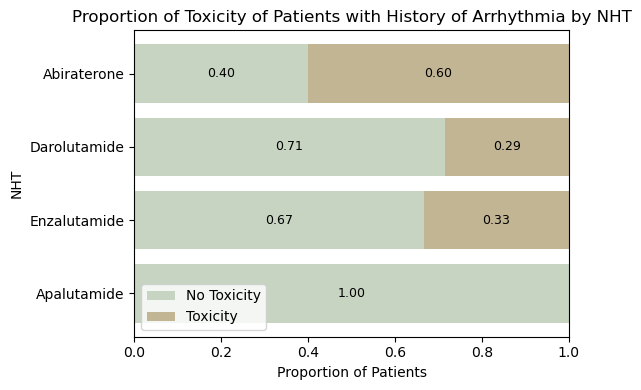

In [136]:
# Counts

arr = df[df['hx_arrhythmia'] == 1]

counts = (
    arr.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, labels=[str(v) if v > 0 else "" for v in counts[0]], label_type='center', fontsize=11)
ax.bar_label(bars_yes, labels=[str(v) if v > 0 else "" for v in counts[1]], label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with History of Arrhythmia by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('NHT')
ax.set_title('Proportion of Toxicity of Patients with History of Arrhythmia by NHT')
ax.legend()

plt.tight_layout()
plt.show()

History of CAD

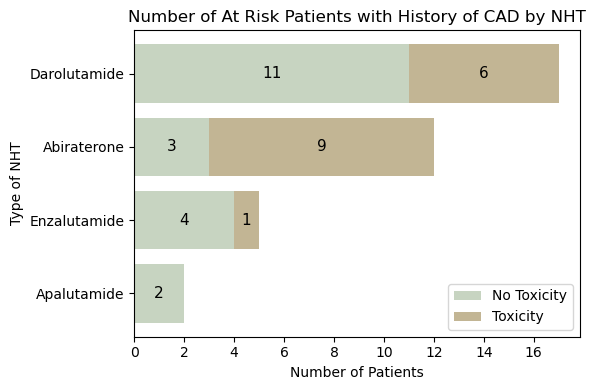

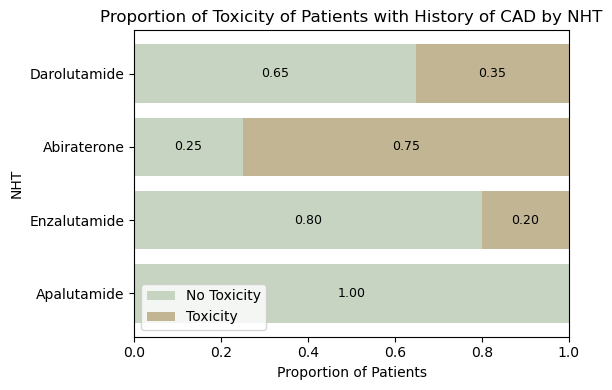

In [137]:
# Counts

cad = df[df['hx_cad'] == 1]

counts = (
    cad.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, labels=[str(v) if v > 0 else "" for v in counts[0]], label_type='center', fontsize=11)
ax.bar_label(bars_yes, labels=[str(v) if v > 0 else "" for v in counts[1]], label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with History of CAD by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('NHT')
ax.set_title('Proportion of Toxicity of Patients with History of CAD by NHT')
ax.legend()

plt.tight_layout()
plt.show()

History of Carotid Disease

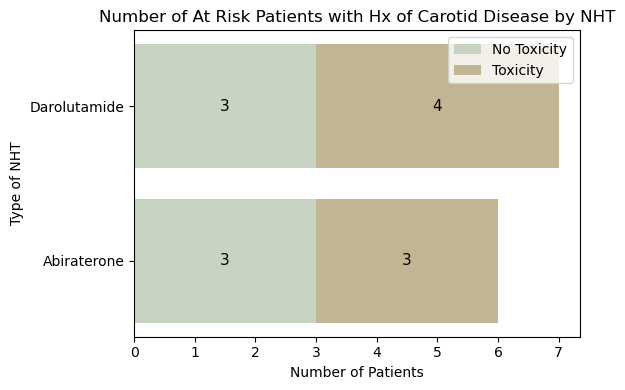

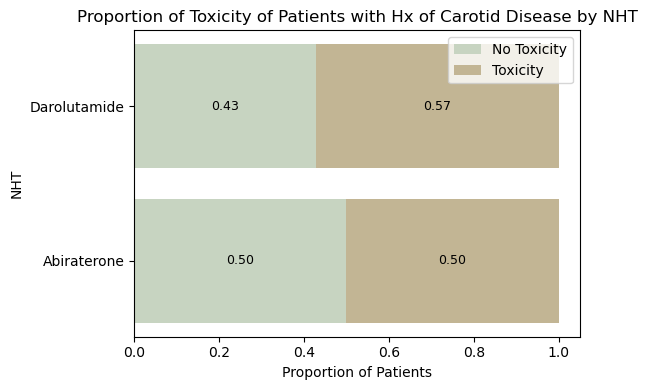

In [138]:
# Counts

car = df[df['hx_carotid'] == 1]

counts = (
    car.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, labels=[str(v) if v > 0 else "" for v in counts[0]], label_type='center', fontsize=11)
ax.bar_label(bars_yes, labels=[str(v) if v > 0 else "" for v in counts[1]], label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with Hx of Carotid Disease by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('NHT')
ax.set_title('Proportion of Toxicity of Patients with Hx of Carotid Disease by NHT')
ax.legend()

plt.tight_layout()
plt.show()

History of PVD / PAD

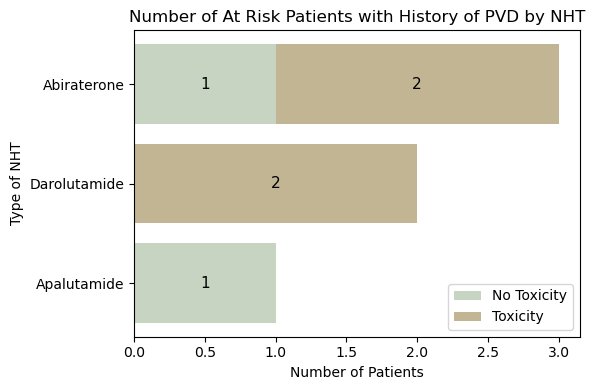

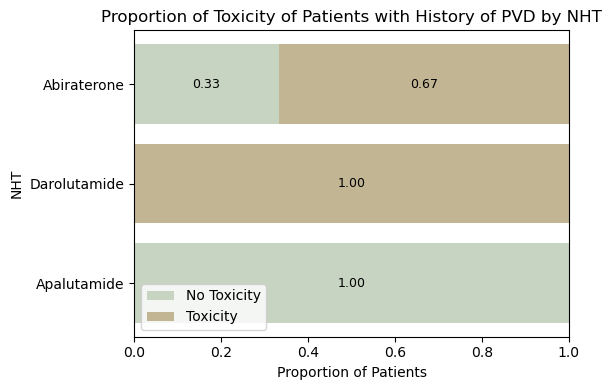

In [139]:
# Counts

pvd = df[df['hx_pad'] == 1]

counts = (
    pvd.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, labels=[str(v) if v > 0 else "" for v in counts[0]], label_type='center', fontsize=11)
ax.bar_label(bars_yes, labels=[str(v) if v > 0 else "" for v in counts[1]], label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with History of PVD by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('NHT')
ax.set_title('Proportion of Toxicity of Patients with History of PVD by NHT')
ax.legend()

plt.tight_layout()
plt.show()

### Cardiology Intervention

Split by ADTs

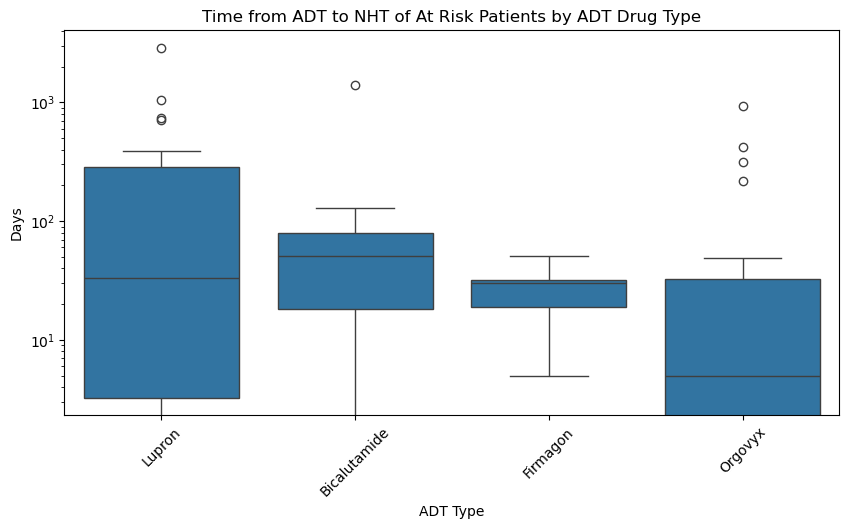

In [52]:
plt.figure(figsize=(10,5))
sns.boxplot(data=tox, x='adt_agent', y='days_adt_to_nht')
plt.yscale('log')
plt.xticks(rotation=45)
plt.title("Time from ADT to NHT of At Risk Patients by ADT Drug Type")
plt.xlabel("ADT Type")
plt.ylabel("Days")
plt.show()

### Cardiology Intervention

Proportion of Patients Receiving Intervention, given Baseline Risk Factor

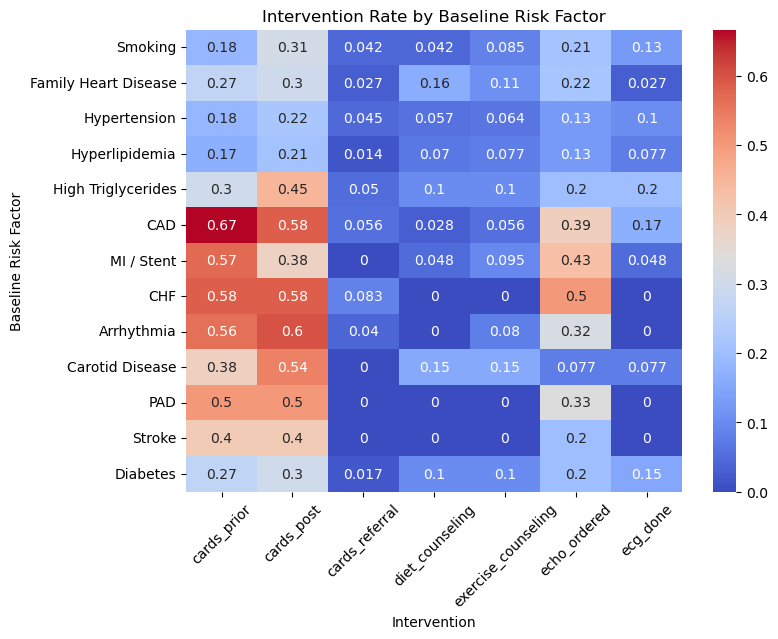

In [88]:
risk_factors = ['hx_smoking', 'family_hx_hd', 'hx_htn','hx_hld','hx_high_tg', 'hx_cad','hx_mi_stent',
                'hx_chf','hx_arrhythmia','hx_carotid','hx_pad','hx_cva','hx_dm2']
interventions = ['cards_prior', 'cards_post', 'cards_referral', 'diet_counseling','exercise_counseling','echo_ordered', 'ecg_done']

condition_names = {
    "hx_smoking": "Smoking",
    "family_hx_hd": "Family Heart Disease",
    "hx_htn": "Hypertension",
    "hx_hld": "Hyperlipidemia",
    "hx_high_tg": "High Triglycerides",
    "hx_cad": "CAD",
    "hx_mi_stent": "MI / Stent",
    "hx_chf": "CHF",
    "hx_arrhythmia": "Arrhythmia",
    "hx_carotid": "Carotid Disease",
    "hx_pad": "PAD",
    "hx_cva": "Stroke",
    "hx_dm2": "Diabetes"
}

heat = pd.DataFrame(index=risk_factors, columns=interventions)

for r in risk_factors:
    for i in interventions:
        heat.loc[r,i] = df[df[r]==1][i].mean()

heat = heat.astype(float)
heat.index = heat.index.map(condition_names)

plt.figure(figsize=(8,6))
sns.heatmap(heat, annot=True, cmap="coolwarm")
plt.xticks(rotation=45)
plt.title("Intervention Rate by Baseline Risk Factor")
plt.xlabel("Intervention")
plt.ylabel("Baseline Risk Factor")
plt.show()

Cardiologist Visits of At Risk Patients

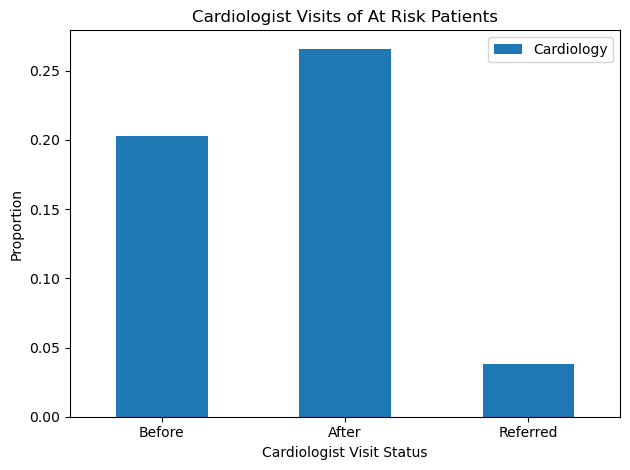

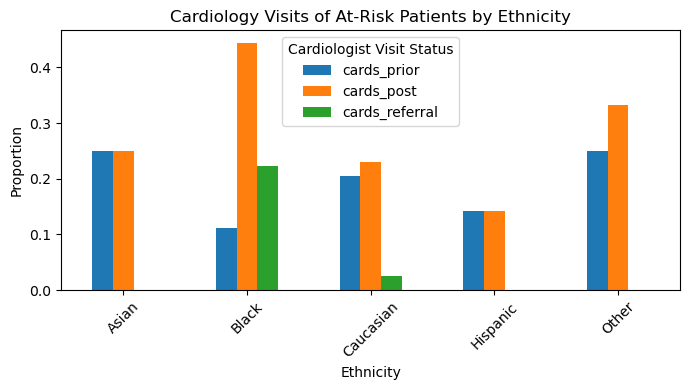

C:\Users\tiffa\AppData\Local\Temp\ipykernel_27760\2151297349.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tox.groupby('age_bin')[['cards_prior', 'cards_post', 'cards_referral']]


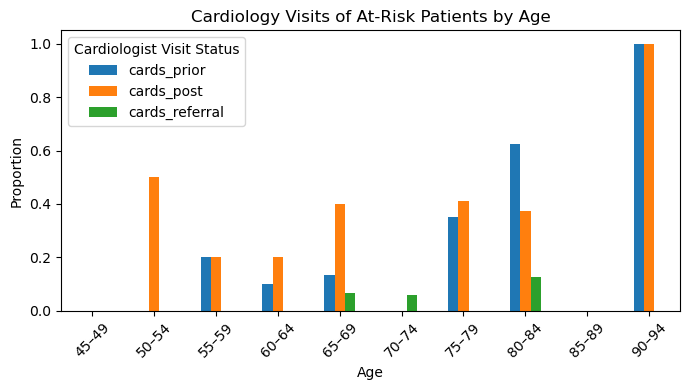

In [89]:
care = pd.DataFrame({
    "Before": tox['cards_prior'].mean(),
    "After": tox['cards_post'].mean(),
    "Referred": tox['cards_referral'].mean()
}, index=["Cardiology"])

care.T.plot(kind='bar')
plt.title("Cardiologist Visits of At Risk Patients")
plt.xticks(rotation=0)
plt.xlabel("Cardiologist Visit Status")
plt.ylabel("Proportion")
plt.tight_layout()

care_race = (
    tox.groupby('ethnicity')[['cards_prior', 'cards_post', 'cards_referral']]
    .mean()
)
care_race.plot(kind='bar', figsize=(7,4))

plt.title("Cardiology Visits of At-Risk Patients by Ethnicity")
plt.xlabel("Ethnicity")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Cardiologist Visit Status")

plt.tight_layout()
plt.show()

care_age = (
    tox.groupby('age_bin')[['cards_prior', 'cards_post', 'cards_referral']]
    .mean()
)
care_age.plot(kind='bar', figsize=(7,4))

plt.title("Cardiology Visits of At-Risk Patients by Age")
plt.xlabel("Age")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Cardiologist Visit Status")

plt.tight_layout()
plt.show()

Preventative Care of At Risk Patients

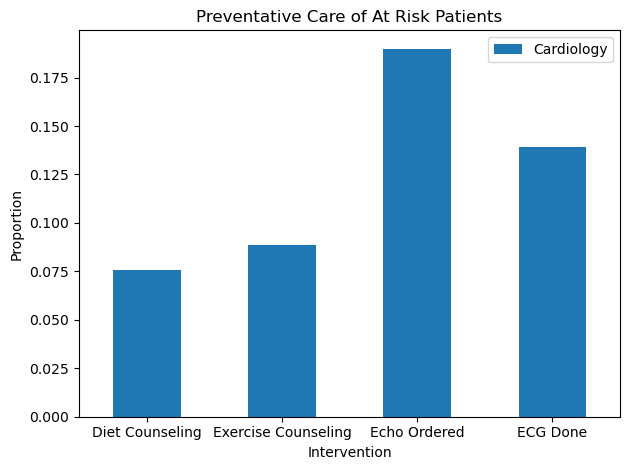

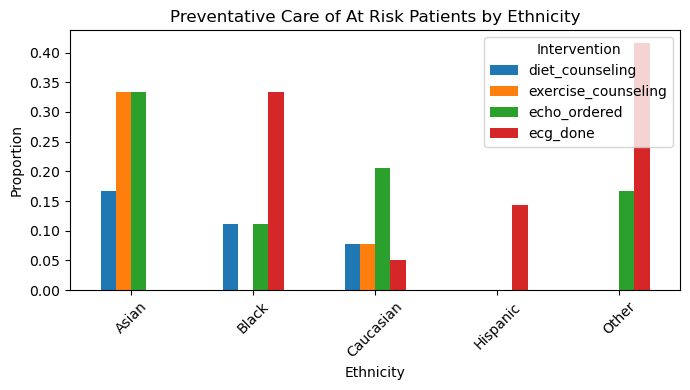

C:\Users\tiffa\AppData\Local\Temp\ipykernel_27760\1867825196.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tox.groupby('age_bin')[['diet_counseling', 'exercise_counseling', 'echo_ordered', 'ecg_done']]


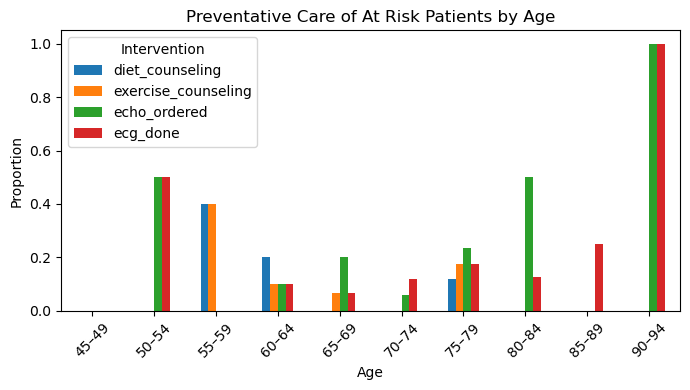

In [90]:
care = pd.DataFrame({
    "Diet Counseling": tox['diet_counseling'].mean(),
    "Exercise Counseling": tox['exercise_counseling'].mean(),
    "Echo Ordered": tox['echo_ordered'].mean(),
    "ECG Done": tox['ecg_done'].mean()
}, index=["Cardiology"])

care.T.plot(kind='bar')
plt.title("Preventative Care of At Risk Patients")
plt.xticks(rotation=0)
plt.xlabel("Intervention")
plt.ylabel("Proportion")
plt.tight_layout()

care_race = (
    tox.groupby('ethnicity')[['diet_counseling', 'exercise_counseling', 'echo_ordered', 'ecg_done']]
    .mean()
)
care_race.plot(kind='bar', figsize=(7,4))

plt.title("Preventative Care of At Risk Patients by Ethnicity")
plt.xlabel("Ethnicity")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Intervention")

plt.tight_layout()
plt.show()

care_age = (
    tox.groupby('age_bin')[['diet_counseling', 'exercise_counseling', 'echo_ordered', 'ecg_done']]
    .mean()
)
care_age.plot(kind='bar', figsize=(7,4))

plt.title("Preventative Care of At Risk Patients by Age")
plt.xlabel("Age")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Intervention")

plt.tight_layout()
plt.show()

### Medication History

BP Treatment Pre-NHT

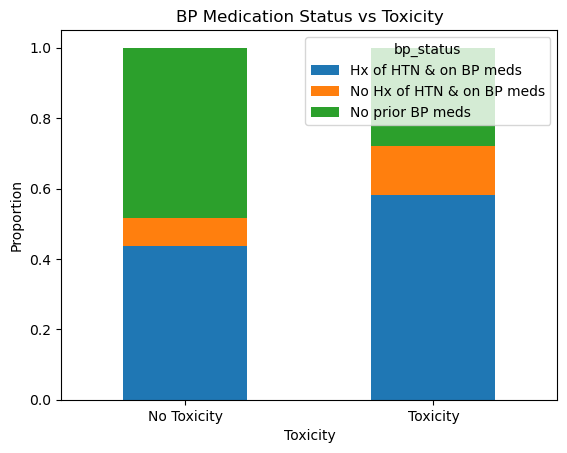

In [143]:
df['bp_status'] = np.select(
    [
        (df['hx_htn']==1) & (df['bp_meds_prior']==1),
        (df['hx_htn']==0) & (df['bp_meds_prior']==1),
        (df['bp_meds_prior']==0)
    ],
    [
        'Hx of HTN & on BP meds',
        'No Hx of HTN & on BP meds',
        'No prior BP meds'
    ],
    default='Other'
)

bp_plot = pd.crosstab(df['bp_status'], df['at_risk'], normalize='columns')

ax = bp_plot.T.plot(kind='bar', stacked=True)
plt.title("BP Medication Status vs Toxicity")
plt.xlabel("Toxicity")
plt.ylabel("Proportion")

ax.set_xticks([0, 1])
ax.set_xticklabels(['No Toxicity', 'Toxicity'], rotation=0)

plt.show()

Diabetes Treatment Pre-NHT

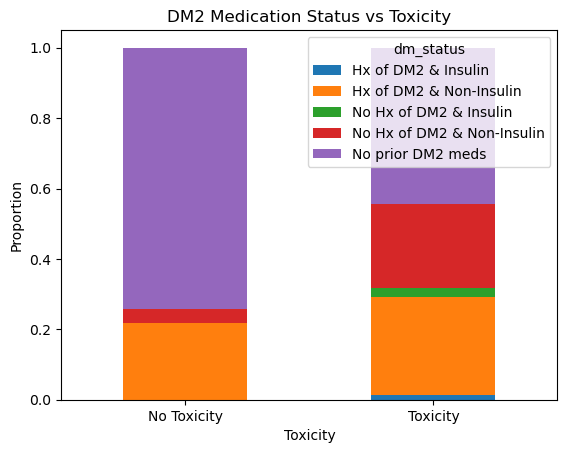

In [137]:
df['dm_status'] = np.select(
    [
        (df['hx_dm2']==1) & (df['dm_noninsulin']==1),
        (df['hx_dm2']==1) & (df['on_insulin']==1),
        (df['hx_dm2']==0) & (df['dm_noninsulin']==1),
        (df['hx_dm2']==0) & (df['on_insulin']==1),
        (df['dm_noninsulin']==0) & (df['on_insulin']==0)
    ],
    [
        'Hx of DM2 & Non-Insulin',
        'Hx of DM2 & Insulin',
        'No Hx of DM2 & Non-Insulin',
        'No Hx of DM2 & Insulin',
        'No prior DM2 meds'
    ],
    default='Other'
)

bp_plot = pd.crosstab(df['dm_status'], df['at_risk'], normalize='columns')

ax = bp_plot.T.plot(kind='bar', stacked=True)
plt.title("DM2 Medication Status vs Toxicity")
plt.xlabel("Toxicity")
plt.ylabel("Proportion")

ax.set_xticks([0, 1])
ax.set_xticklabels(['No Toxicity', 'Toxicity'], rotation=0)

plt.show()

HLD Treatment Pre-NHT

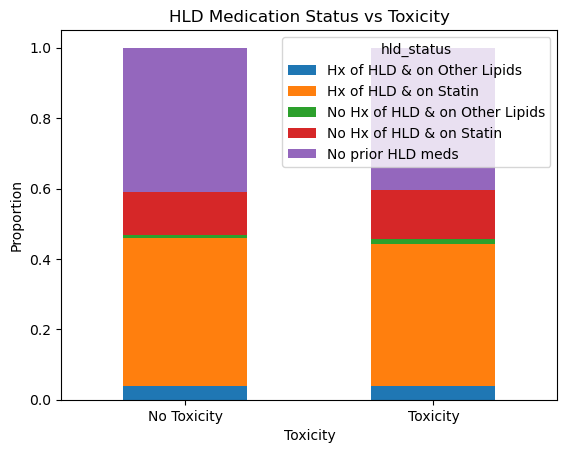

In [142]:
df['hld_status'] = np.select(
    [
        (df['hx_hld']==1) & (df['statin_prior']==1),
        (df['hx_hld']==1) & (df['other_lipid_prior']==1),
        (df['hx_hld']==0) & (df['statin_prior']==1),
        (df['hx_hld']==0) & (df['other_lipid_prior']==1),
        (df['statin_prior']==0) & (df['other_lipid_prior']==0)
    ],
    [
    'Hx of HLD & on Statin',
    'Hx of HLD & on Other Lipids',
    'No Hx of HLD & on Statin',
    'No Hx of HLD & on Other Lipids',
    'No prior HLD meds'
    ],
    default='Other'
)

statin_plot = pd.crosstab(df['hld_status'], df['at_risk'], normalize='columns')

ax = statin_plot.T.plot(kind='bar', stacked=True)
plt.title("HLD Medication Status vs Toxicity")
plt.xlabel("Toxicity")
plt.ylabel("Proportion")

ax.set_xticks([0, 1])
ax.set_xticklabels(['No Toxicity', 'Toxicity'], rotation=0)

plt.show()